# **scCellFie analysis on the Slide-seq lung dataset**

## Imports

In [1]:
import sccellfie

import scanpy as sc
import squidpy as sq

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung"
ADATA_PATH = f"{BASE_PATH}/h5ads"
DATA_PATH = f"{BASE_PATH}/data"
PLOTS_PATH = f"{BASE_PATH}/plots"

/home/projects/nyosef/oier/mambaforge/envs/sccellfie-dev/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/projects/nyosef/oier/mambaforge/envs/sccellfie-dev/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/projects/nyosef/oier/mambaforge/envs/sccellfie-dev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import ann

In [2]:
adata = sc.read_h5ad(f"{ADATA_PATH}/Slide_seq_lung_adata.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 200394 × 21387
    obs: 'n_genes', 'n_UMIs', 'log10_n_UMIs', 'log10_n_genes', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'Cell_Type', 'cell_type_ontology_term_id', 'donor_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'sample'
    obsm: 'spatial'
    layers: 'counts', 'log_norm', 'normalized'

In [4]:
samples = ['Puck_200727_08', 'Puck_200727_09', 'Puck_200727_10']
adata = adata[adata.obs['sample'].isin(samples)].copy()

In [5]:
results = sccellfie.run_sccellfie_pipeline(adata,
                                           organism='human',
                                           sccellfie_data_folder=None,
                                           n_counts_col='n_UMIs',
                                           process_by_group=False,
                                           groupby=None,
                                           neighbors_key='neighbors',
                                           n_neighbors=10,
                                           batch_key='sample',
                                           threshold_key='sccellfie_threshold',
                                           smooth_cells=True,
                                           alpha=0.33,
                                           chunk_size=5000,
                                           disable_pbar=False,
                                           save_folder=None,
                                           save_filename=None
                                          )


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: human

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----

---- scCellFie Step: Computing neighbors ----

---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 22
Shape of new adata object: (49207, 850)
Number of GPRs: 760
Shape of tasks by genes: (218, 850)
Shape of reactions by genes: (760, 850)
Shape of tasks by reactions: (218, 760)

---- scCellFie Step: Smoothing gene expression ----


Smoothing Expression: 100%|██████████| 10/10 [00:02<00:00,  4.41it/s]



---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|██████████| 49207/49207 [03:05<00:00, 265.17it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 2 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


In [6]:
results.keys()

dict_keys(['adata', 'gpr_rules', 'task_by_gene', 'rxn_by_gene', 'task_by_rxn', 'rxn_info', 'task_info', 'thresholds', 'organism'])

In [11]:
sccellfie.io.save_adata(adata=results['adata'], output_directory=ADATA_PATH, filename='Slide_seq_lung_scCellFie')

/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung/h5ads/Slide_seq_lung_scCellFie.h5ad was correctly saved
/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung/h5ads/Slide_seq_lung_scCellFie_reactions.h5ad was correctly saved
/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung/h5ads/Slide_seq_lung_scCellFie_metabolic_tasks.h5ad was correctly saved


Puck_200727_09


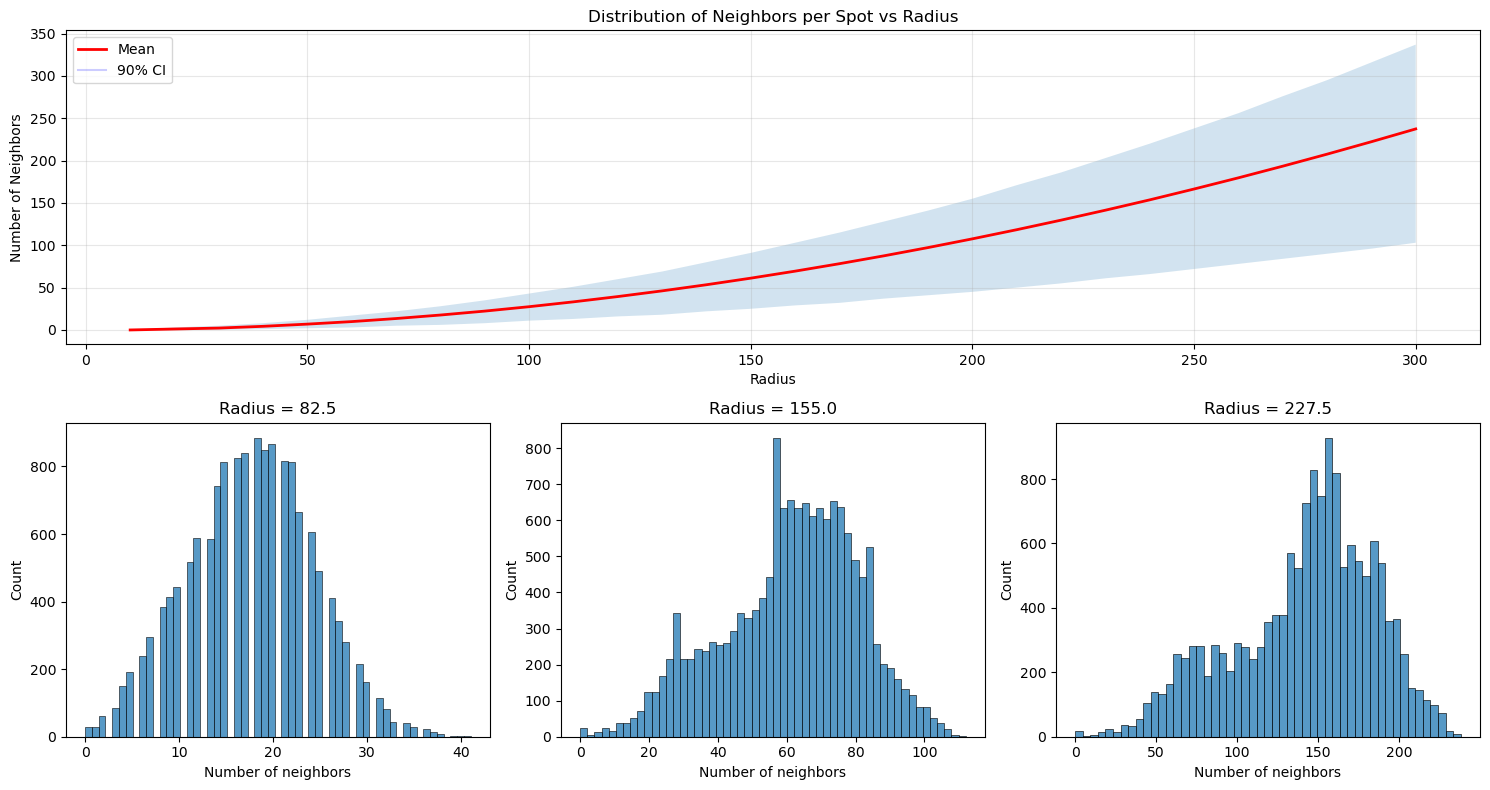

Puck_200727_10


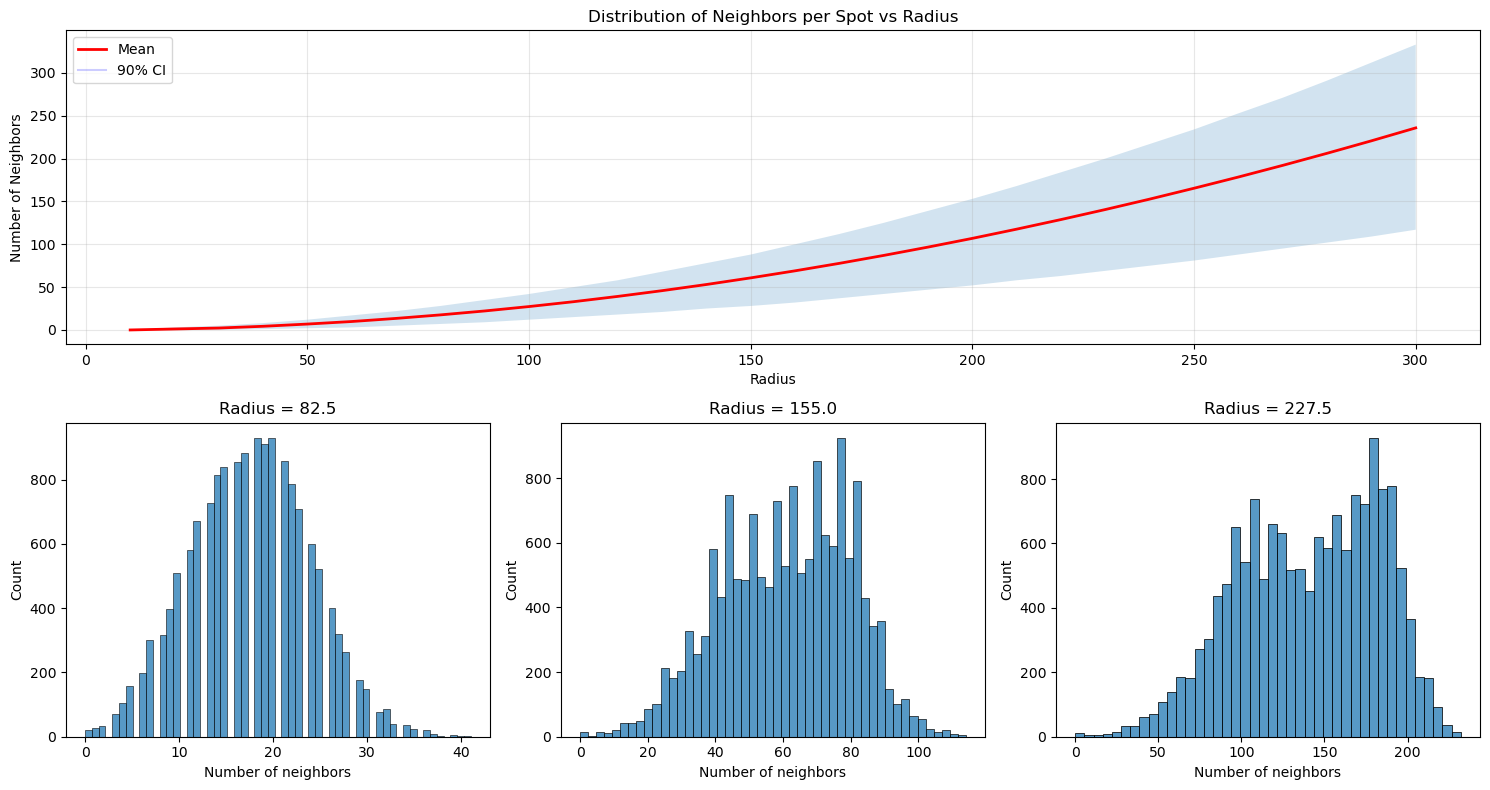

Puck_200727_08


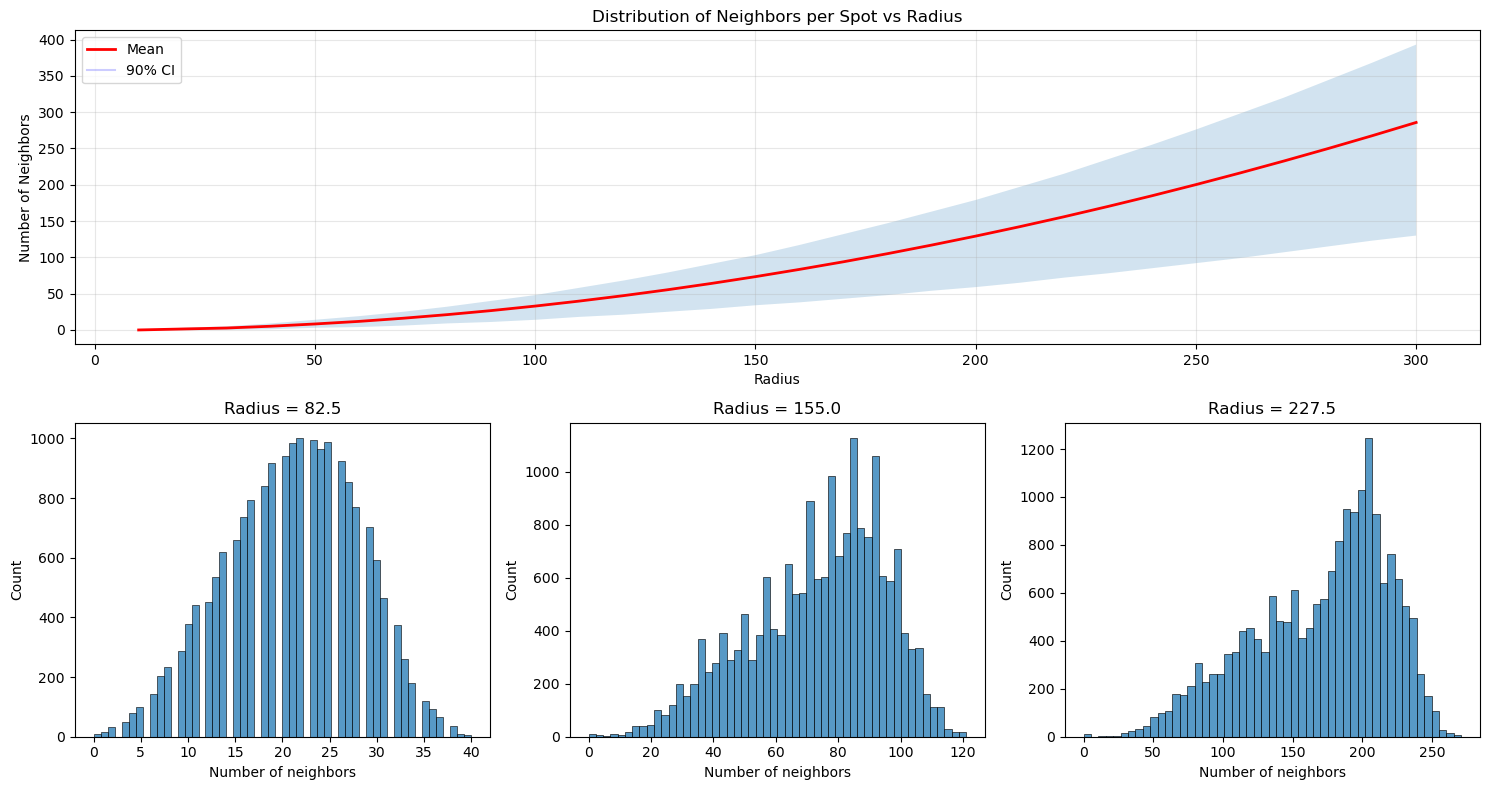

In [20]:
for sample in adata.obs['sample'].unique():
    print(sample)
    sample_adata = adata[adata.obs['sample'] == sample].copy()
    r = sccellfie.spatial.compute_neighbor_distribution(
        sample_adata,
        radius_range=(10, 300),  # adjust based on your data's scale
        n_points=30,
        spatial_key='spatial'
    )
    sccellfie.plotting.spatial.plot_neighbor_distribution(r)
    plt.show()

In [26]:
"""
Benchmark: Harreman vs scCellFie
=================================
Computes local colocalization scores between metabolic task ligands
and receptor genes for the 5 axes described by the scCellFie authors:

  1. E2 synthesis (from androstenedione)  → ESR1, ESR2
  2. Thromboxane synthesis (from arachidonate) → TBXA2R
  3. GABA synthesis                        → GABRA1, GABRG2
  4. Testosterone synthesis (from androstenedione) → AR
  5. Dopamine synthesis (tyrosine → dopamine) → DRD1–DRD5

Usage
-----
    # In your notebook / script, after running the scCellFie pipeline:
    #
    #   results = sccellfie.run_sccellfie_pipeline(adata, ...)
    #
    # Then:
    #   import benchmark_harreman_sccellfie as bm
    #   adata_updated = bm.build_adata_updated(adata, results)
    #   bm.inspect_task_names(adata_updated)          # confirm task names first
    #   adata_updated = bm.run_colocalization(adata_updated, task_name_map)
    #   bm.summarise(adata_updated)
"""

import re
import warnings
import numpy as np
import pandas as pd
import sccellfie

In [27]:
# ---------------------------------------------------------------------------
# Step 1 — Merge metabolic task scores into the gene-expression AnnData
# ---------------------------------------------------------------------------

def build_adata_updated(adata, results):
    """
    Transfer metabolic task scores from results.metabolic_tasks into adata
    (which already carries gene expression in .X and spatial coords in
    .obsm['spatial']).

    Parameters
    ----------
    adata : AnnData
        Original object with gene expression + spatial coordinates.
    results : scCellFie pipeline output
        Must expose a .metabolic_tasks AnnData attribute.

    Returns
    -------
    adata_updated : AnnData
        adata extended with metabolic task variables.
    """
    adata_updated = sccellfie.preprocessing.adata_utils.transfer_variables(
        adata_target=adata,
        adata_source=results['adata'].metabolic_tasks,
        var_names=results['adata'].metabolic_tasks.var_names
    )
    print(
        f"adata_updated: {adata_updated.n_obs} cells × {adata_updated.n_vars} vars "
        f"({adata.n_vars} genes + {results['adata'].metabolic_tasks.n_vars} tasks)"
    )
    return adata_updated


# ---------------------------------------------------------------------------
# Step 2 — Inspect task names and map them to the 5 metabolic axes
# ---------------------------------------------------------------------------

# Keywords to search for in var_names (case-insensitive)
SEARCH_TERMS = {
    "E2 / estradiol":    [r"estradiol", r"\be2\b", r"17.?beta"],
    "thromboxane":       [r"thromboxane"],
    "GABA":              [r"\bgaba\b", r"gamma.?aminobutyric"],
    "testosterone":      [r"testosterone"],
    "dopamine":          [r"dopamine", r"tyrosine.*dopamine", r"dopa"],
}


def inspect_task_names(adata_updated):
    """
    Print metabolic task var_names that match each of the 5 axes.
    Review the output and pass the confirmed names to run_colocalization()
    via task_name_map.
    """
    # Separate task vars from gene vars using the 'type' metadata if present,
    # otherwise fall back to all var_names that are not in common gene-name
    # format (all-caps short token).
    if "type" in adata_updated.var.columns:
        task_vars = adata_updated.var_names[
            adata_updated.var["type"] == "metabolic score"
        ].tolist()
    else:
        # heuristic: task names tend to be longer / contain spaces
        task_vars = [v for v in adata_updated.var_names if " " in v or len(v) > 10]

    print("=" * 60)
    print("Metabolic task name inspection")
    print("=" * 60)
    for axis, patterns in SEARCH_TERMS.items():
        matches = []
        for name in task_vars:
            for pat in patterns:
                if re.search(pat, name, re.IGNORECASE):
                    matches.append(name)
                    break
        print(f"\n[{axis}]")
        if matches:
            for m in matches:
                print(f"  ✓  {m!r}")
        else:
            print("  ✗  No matches found — check var_names manually")

    print("\n" + "=" * 60)
    print("All task var_names (for manual inspection):")
    for v in sorted(task_vars):
        print(f"  {v!r}")


# ---------------------------------------------------------------------------
# Step 3 — Define ligand→receptor pairs and run colocalization scoring
# ---------------------------------------------------------------------------

def _default_task_name_map():
    """
    Placeholder task names based on common scCellFie naming conventions.
    Replace values with the exact strings from inspect_task_names().
    """
    return {
        "E2":          "Synthesis of estradiol-17beta (E2) from androstenedione",
        "thromboxane": "Synthesis of thromboxane from arachidonate",
        "GABA":        "Synthesis of GABA",
        "testosterone":"Synthesis of testosterone from androstenedione",
        "dopamine":    "Tyrosine to dopamine",
    }


def _build_pairs(task_name_map):
    """
    Build the list of (obs_col_name, var1, var2_list) tuples.
    """
    tm = task_name_map
    pairs = [
        # (obs column name,   ligand task,         receptor gene(s))
        ("E2__ESR1",          tm["E2"],             ["ESR1"]),
        ("E2__ESR2",          tm["E2"],             ["ESR2"]),
        ("thromboxane__TBXA2R", tm["thromboxane"],  ["TBXA2R"]),
        ("GABA__GABRA1",      tm["GABA"],           ["GABRA1"]),
        ("GABA__GABRG2",      tm["GABA"],           ["GABRG2"]),
        ("testosterone__AR",  tm["testosterone"],   ["AR"]),
        ("dopamine__DRD1",    tm["dopamine"],        ["DRD1"]),
        ("dopamine__DRD2",    tm["dopamine"],        ["DRD2"]),
        ("dopamine__DRD3",    tm["dopamine"],        ["DRD3"]),
        ("dopamine__DRD4",    tm["dopamine"],        ["DRD4"]),
        ("dopamine__DRD5",    tm["dopamine"],        ["DRD5"]),
    ]
    return pairs


def run_colocalization(
    adata_updated,
    task_name_map=None,
    neighbors_radius=100,
    method="pairwise_concordance",
    min_neighbors=3,
    spatial_key="spatial",
):
    """
    Same as before but operates on a single-sample AnnData slice.
    Scores are written into adata_updated.obs and returned as a DataFrame.
    """
    if task_name_map is None:
        warnings.warn(
            "task_name_map not provided — using placeholder task names. "
            "Run inspect_task_names() first and pass confirmed names.",
            UserWarning,
        )
        task_name_map = _default_task_name_map()

    pairs = _build_pairs(task_name_map)

    scored_cols = []
    for obs_col, var1, var2_list in pairs:
        missing = [v for v in [var1] + var2_list if v not in adata_updated.var_names]
        if missing:
            warnings.warn(
                f"Skipping '{obs_col}': variables not found in adata_updated: {missing}"
            )
            continue

        print(f"  Scoring  {obs_col!r}  |  '{var1}'  →  {var2_list} ...", end="  ")
        try:
            scores = sccellfie.communication.compute_local_colocalization_scores(
                adata_updated,
                var1=var1,
                var2=var2_list,
                neighbors_radius=neighbors_radius,
                method=method,
                min_neighbors=min_neighbors,
                spatial_key=spatial_key,
                inplace=False,
            )
            adata_updated.obs[obs_col] = scores
            scored_cols.append(obs_col)
            n_scored = (~np.isnan(scores)).sum() if hasattr(scores, "__len__") else "?"
            print(f"done  ({n_scored} cells scored)")
        except Exception as exc:
            print(f"FAILED — {exc}")

    print(f"  → {len(scored_cols)}/{len(pairs)} pairs scored successfully.")
    results_df = adata_updated.obs[scored_cols].copy()
    return adata_updated, results_df


# ---------------------------------------------------------------------------
# Step 4 — Summarise results
# ---------------------------------------------------------------------------

def summarise(adata_updated, results_df=None):
    """
    Print a summary table of mean colocalization scores per scored pair,
    and report how many cells have a non-NaN score for each pair.
    """
    # Auto-detect scored columns if results_df not provided
    if results_df is None:
        axes = list(_default_task_name_map().keys())
        scored_cols = [
            c for c in adata_updated.obs.columns
            if any(c.startswith(a) for a in
                   ["E2__", "thromboxane__", "GABA__", "testosterone__", "dopamine__"])
        ]
        results_df = adata_updated.obs[scored_cols]

    if results_df.empty:
        print("No scored columns found.")
        return

    summary = pd.DataFrame({
        "n_cells_scored": results_df.notna().sum(),
        "mean_score":     results_df.mean(),
        "median_score":   results_df.median(),
        "std_score":      results_df.std(),
    })
    summary.index.name = "pair"
    summary = summary.sort_values("mean_score", ascending=False)

    print("\n" + "=" * 60)
    print("Colocalization score summary")
    print("=" * 60)
    print(summary.to_string(float_format="{:.4f}".format))
    print("=" * 60)
    return summary


# ---------------------------------------------------------------------------
# Convenience: run everything end-to-end
# ---------------------------------------------------------------------------

def run_benchmark(adata, results, task_name_map, **kwargs):
    """
    End-to-end convenience wrapper.

    Parameters
    ----------
    adata : AnnData
        Gene expression + spatial AnnData.
    results : scCellFie pipeline output
    task_name_map : dict
        Confirmed task names from inspect_task_names().
    **kwargs
        Passed to run_colocalization() (neighbors_radius, method, etc.).

    Returns
    -------
    adata_updated : AnnData
    results_df : pd.DataFrame
    summary : pd.DataFrame
    """
    adata_updated = build_adata_updated(adata, results)
    adata_updated, results_df = run_colocalization(
        adata_updated, task_name_map=task_name_map, **kwargs
    )
    summary = summarise(adata_updated, results_df)
    return adata_updated, results_df, summary



def run_benchmark_per_sample(
    adata,
    results,
    task_name_map,
    sample_key="sample_id",
    **kwargs,
):
    """
    Run the colocalization benchmark separately for each sample, then merge
    the per-sample scores back into a single AnnData covering all cells.

    Parameters
    ----------
    adata : AnnData
        Full gene expression + spatial AnnData (all samples).
    results : scCellFie pipeline output
    task_name_map : dict
        Confirmed task names from inspect_task_names().
    sample_key : str
        Column in adata.obs that identifies each sample (default: 'sample_id').
    **kwargs
        Passed to run_colocalization() (neighbors_radius, method, etc.).

    Returns
    -------
    adata_updated : AnnData
        Full AnnData with colocalization scores in .obs for every cell.
    all_results : dict[str, pd.DataFrame]
        Per-sample results DataFrames keyed by sample name.
    all_summaries : dict[str, pd.DataFrame]
        Per-sample summary tables keyed by sample name.
    """
    if sample_key not in adata.obs.columns:
        raise ValueError(f"'{sample_key}' not found in adata.obs.columns.")

    samples = adata.obs[sample_key].unique()
    print(f"Found {len(samples)} samples: {list(samples)}\n")

    # Build the full merged AnnData first (gene expression + task scores)
    adata_updated_full = build_adata_updated(adata, results)

    # Collect scored obs columns across samples to pre-allocate NaN columns
    all_results  = {}
    all_summaries = {}
    scored_cols_global = set()

    per_sample_obs = {}  # sample -> obs DataFrame with scores

    for sample in samples:
        print(f"{'='*60}")
        print(f"Sample: {sample!r}")
        print(f"{'='*60}")

        # Slice to this sample only
        mask = adata_updated_full.obs[sample_key] == sample
        adata_sample = adata_updated_full[mask].copy()

        # Run colocalization on the sample slice
        adata_sample, results_df = run_colocalization(
            adata_sample,
            task_name_map=task_name_map,
            **kwargs,
        )

        scored_cols = results_df.columns.tolist()
        scored_cols_global.update(scored_cols)

        # Store per-sample results and summary
        all_results[sample]   = results_df
        all_summaries[sample] = summarise(adata_sample, results_df)

        # Keep the scored obs rows indexed by cell barcode
        per_sample_obs[sample] = adata_sample.obs[scored_cols]
        print()

    # --- Merge scores back into the full AnnData ---
    scored_cols_global = sorted(scored_cols_global)

    # Initialise all score columns as NaN
    for col in scored_cols_global:
        adata_updated_full.obs[col] = np.nan

    # Fill in per-sample scores using the cell index
    for sample, obs_df in per_sample_obs.items():
        adata_updated_full.obs.loc[obs_df.index, obs_df.columns] = obs_df.values

    print(f"{'='*60}")
    print(f"Done. Scores merged for {len(samples)} samples.")
    print(f"Scored columns in adata_updated.obs: {scored_cols_global}")

    return adata_updated_full, all_results, all_summaries

In [29]:
adata_updated, all_results, all_summaries = run_benchmark_per_sample(
    adata, results, task_name_map=None,
    sample_key="sample",          # <-- adjust to your column name
    neighbors_radius=100,
    method="pairwise_concordance",
    min_neighbors=3,
    spatial_key="spatial",
)

Found 3 samples: ['Puck_200727_09', 'Puck_200727_10', 'Puck_200727_08']

adata_updated: 49207 cells × 21603 vars (21387 genes + 216 tasks)
Sample: 'Puck_200727_09'
  Scoring  'E2__ESR1'  |  'Synthesis of estradiol-17beta (E2) from androstenedione'  →  ['ESR1'] ...  done  (14956 cells scored)
  Scoring  'E2__ESR2'  |  'Synthesis of estradiol-17beta (E2) from androstenedione'  →  ['ESR2'] ...  done  (14956 cells scored)
  Scoring  'thromboxane__TBXA2R'  |  'Synthesis of thromboxane from arachidonate'  →  ['TBXA2R'] ...  done  (14956 cells scored)
  Scoring  'GABA__GABRG2'  |  'Synthesis of GABA'  →  ['GABRG2'] ...  done  (14956 cells scored)
  Scoring  'testosterone__AR'  |  'Synthesis of testosterone from androstenedione'  →  ['AR'] ...  done  (14956 cells scored)
  Scoring  'dopamine__DRD2'  |  'Tyrosine to dopamine'  →  ['DRD2'] ...  done  (14956 cells scored)
  Scoring  'dopamine__DRD3'  |  'Tyrosine to dopamine'  →  ['DRD3'] ...  done  (14956 cells scored)
  Scoring  'dopamine__DRD4

In [30]:
# adata_updated.write(f"{ADATA_PATH}/Slide_seq_lung_CCC_scCellFie.h5ad")